Stripe only downlink example
----------------------------
This notebook shows how to use the stripe to send a QAM signal downlink towards the active radio unit. The signal travels up to the antenna of the active radio unit. Varying the fiber, coupler and amplifier parameters allows to inspect their impact on the AM/AM and PSD plots. These are plotted at the end of the notebook for every stage in the link.

In [27]:
import yaml
import numpy as np
import matplotlib.pyplot as plt

from plotter import plotter
from utils import calculate_psd_per_symbol
from wireless_channel.waveforms import Waveform
from sub_THz_stripe.radiostripe.radiostripe import RadioStripe
from sub_THz_stripe.central_unit.central_unit import CentralUnit

In [28]:
# Read out the config file.
config_file = "examples/stripe_dl/config.yml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

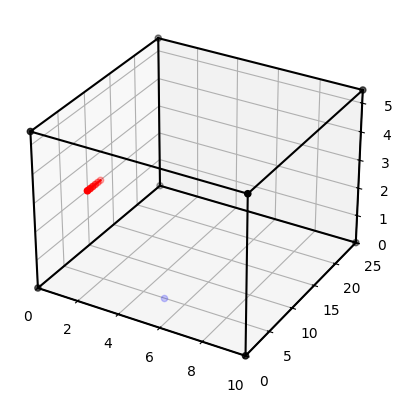

In [29]:
# Plot the room with the strip in it.
plotter.plot_room(config)

In [30]:
# Construct the waveform class based on the loaded configuration.
waveform_config = config["waveform_config"]
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

In [31]:
# Build the RadioStripe object based on the configuration.
component_config = config["component_config"]
stripe_cfg = config["radio_stripes"][0]
rs = RadioStripe.from_config_locations(stripe_cfg, component_config, wf)

In [32]:
# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)

In [33]:

cu = CentralUnit()  # todo are these configs loadable?
ofdm_time_after_cu = cu.run(ofdm_time)  # shape: nr_ofdm_symbols x (fft_size + cp length)

In [34]:

# The last unit is the active one.
rs.active_unit = 5

# Optional calibration of the radio stripe amplifiers.
rs.calibrate(ofdm_time_after_cu, -30)

# Transmit the data over the stripe.
phase_shifts = [0, 0, 0, 0]
iq_out, imdata = rs.transmit(ofdm_time_after_cu, phase_shifts)

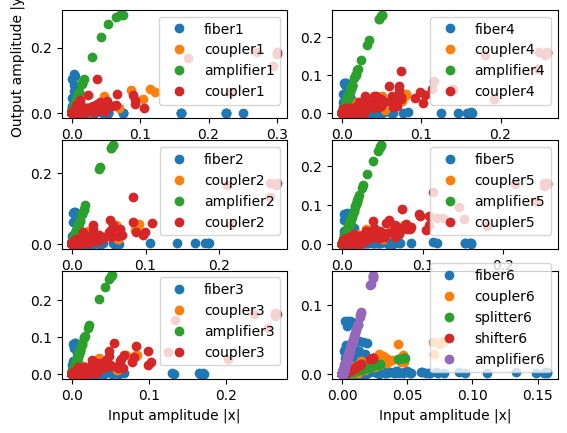

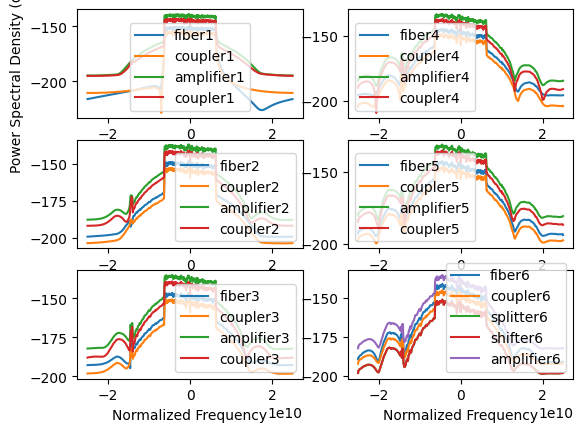

In [35]:
booster_stages = ["fiber", "coupler", "amplifier", "coupler"]
tx_stages = ["fiber", "coupler", "splitter", "shifter", "amplifier"]

# Make AM/AM plots for every stage in the stripe.
stages = ((len(imdata) - 6) // 4) + 1
plot_panes = stages
if stages % 2 != 0:
    plot_panes += 1

# Make spec plots for every stage in the stripe.
fig, ax = plt.subplots(plot_panes // 2, 2)
fig2, ax2 = plt.subplots(plot_panes // 2, 2)

# Keep the array 1xm for simplicity.
if len(ax.shape) == 1:
    ax = np.array([ax])
if len(ax2.shape) == 1:
    ax2 = np.array([ax2])

# Set the proper axis labels.
ax[-1, 0].set_xlabel("Input amplitude |x|")
ax[-1, -1].set_xlabel("Input amplitude |x|")
ax[0, 0].set_ylabel("Output amplitude |y|")

ax2[-1, 0].set_xlabel("Normalized Frequency")
ax2[-1, -1].set_xlabel("Normalized Frequency")
ax2[0, 0].set_ylabel("Power Spectral Density (dB/Hz)")

# Loop over the data from all the stages. (Stages are RUs and BUs.)
for i in range(len(imdata) - 1):
    # Calculate at which stage we are.
    stage = (i // 4) + 1
    # The last stage is a RU containing 5 components instead of 4. We need to
    # compensate for this or we advance to a non-existing stage.
    if stage > stages:
        stage = stages

    # Extract the data going into the stage and coming out of it.
    x = imdata[i][0]
    y = imdata[i + 1]
    # If the matrix is three dimensional we need to extract one level deeper.
    if len(imdata[i].shape) >= 3:
        x = imdata[i][0][0]
    if len(imdata[i + 1].shape) >= 3:
        y = imdata[i + 1][0]

    # Calculate the PSD.
    freq, psd = calculate_psd_per_symbol(y, wf.fs)

    if stage >= stages:
        label = tx_stages[i % 5]
        label += str(stages)
    else:
        label = booster_stages[i % 4]
        label += str((i // 4) + 1)
    column = 0
    if stage > (plot_panes // 2):
        column = 1
    row = (stage - 1) % (plot_panes // 2)

    ax[row, column].plot(np.abs(x), np.abs(y[0]), "o", label=label)
    ax[row, column].legend()

    ax2[row, column].plot(freq, psd, label=label)
    ax2[row, column].legend()